### 1. Descripción General del Proyecto
Este proyecto consiste en un análisis exploratorio de datos (EDA) sobre el mercado de alquiler residencial en dos mercados geográficos distintos:  
•	Santiago de Chile: distritos de Ñuñoa, Las Condes y Lo Barnechea (fuente: chilepropiedades.cl)  
•	Madrid, España: zona norte cercana a Tetuán (fuente: idealista.com)

El objetivo principal es analizar la distribución de precios entre distritos, comparar comunas/barrios, estudiar la relación entre precio y superficie, y detectar patrones estadísticos relevantes mediante técnicas de webscraping y análisis estadístico.


#### 2. Fuentes de Datos y Scraping
##### 2.1 Chile — chilepropiedades.cl
Se utilizó Selenium con undetected-chromedriver para hacer web scrapping y extraer los siguientes campos por propiedad:



| Campo | Descripción |
|--------------|--------------|
|titulo|	Dirección/nombre de la propiedad|
|precio|	Precio mensual en pesos chilenos (CLP)|
|dormitorios|	Número de dormitorios|
|baños|	Número de baños|
|m2|	Superficie total en metros cuadrados|
|codigo	|Código identificador único|
|estacionamientos|	Número de estacionamientos|
|fecha|	Fecha de publicación del anuncio|



Distritos estudiados: 

•	Ñuñoa: 353 pisos de de chilepropiedades.cl  
•	Las Condes: 265 pisos de de chilepropiedades.cl  
•	Lo Barnechea: 48 pisos de de chilepropiedades.cl  

Número de registros obtenidos: 666 en total.

##### 2.2 Madrid — idealista.com
Se realizó webscraping de la zona norte de Madrid cercana al barrio de Tetuán utilizando la funcionalidad de búsqueda por área geográfica de idealista.com. Se extrajeron 695 propiedades en 24 páginas.



| Campo | Descripción |
|--------------|--------------|
|titulo|	Dirección/nombre de la propiedad|
|titulo| tipo de vivienda y dirección |
|precio| precio mensual en euros |
|habitaciones| número de habitaciones|
|m2| superficie en metros cuadrados|
|altura| planta y características del piso (ej. 'Planta 1ª exterior con ascensor')|
|zona| barrio y ciudad (extraída del título mediante regex)|


#### 2.3 Información del Sitio Web Expatistan

Se usó como referencia el gráfico comparativo del costo de vida de ambos sitios, Madrid y SCL. Ellos indican que el promedio Madrid es un 49% más caro que SCL.



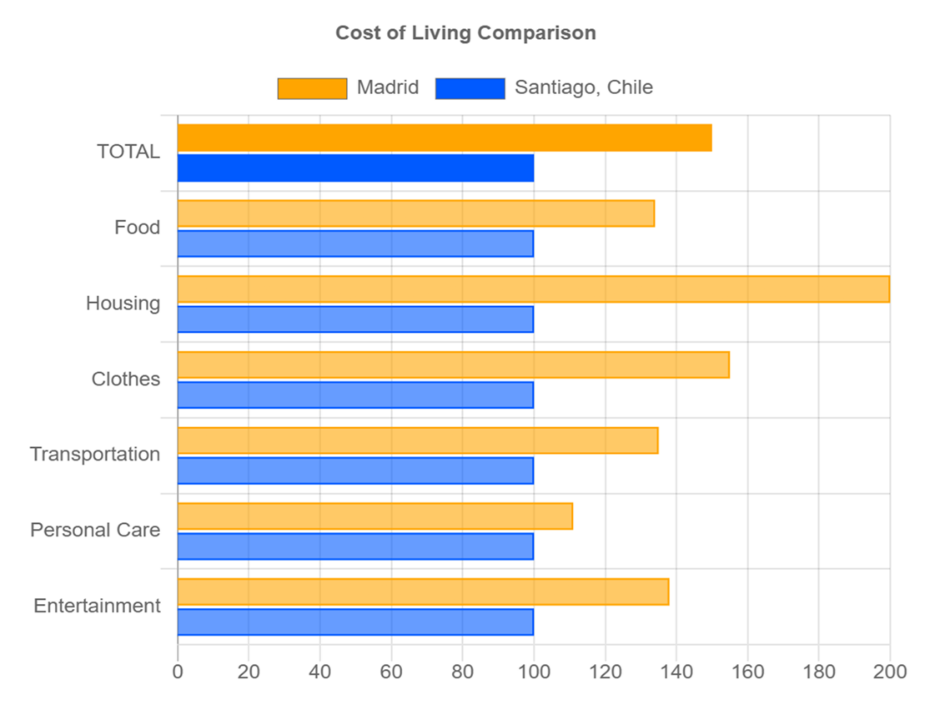

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('Costofliving_expatistan.png')

plt.figure(figsize=(12, 10)) 
plt.imshow(img)
plt.axis('off')
plt.show()

#### 3. Stack Tecnológico
##### 3.1 Web Scraping
•	Python 3.11  
•	Selenium + ChromeDriver (webdriver_manager)  
•	undetected-chromedriver: evasión de sistemas anti-bot  
•	pandas + numpy: manipulación de datos  
•	WebDriverWait / EC: esperas 



3.2 Análisis y Visualización  
•	pandas: limpieza, transformación y agrupación de datos  
•	bootcampviztools: librería personalizada para generar gráficos personalizados  
•	matplotlib / seaborn: gráficos  
•	scipy.stats: tests estadísticos (se utilizó ANOVA)  


#### 4. Procesamiento de Datos
##### 4.1 Limpieza de datos (Chile)


•	Conversión del precio (a fornato numérico):  
df_inm['precio'] = pd.to_numeric(df_inm['precio'].str.replace('$', '').str.replace('.', '').str.strip())

•	Conversión de la superficie:  
df_inm['m2'] = pd.to_numeric(df_inm['m2'].str.replace(' m²', '').str.replace(',', '.'))

•	Conversión a euros (tipo de cambio: 1 CLP = 0.00094 EUR):  
df_inm['precio_eu'] = df_inm['precio'] * 0.00094

•	Cálculo del precio por metro cuadrado:  
df_inm['precioeu_m2'] = df_inm['precio_eu'] / df_inm['m2']

•	Otros:   
dropna(): eliminación de filas con valores nulos  
Estacionamientos: los valores 'N/A' se reemplazan por 0  
Título: se elimina texto redundante como 'Publicación Reciente'  
código: se extrae solo el número identificador del texto completo  


##### 4.2 Eliminación de outliers
Se aplica un filtro por percentiles p5 y p95 sobre el precio en euros (o precio/m² según el análisis) para eliminar registros anómalos. Este proceso elimina aproximadamente el 10% de los datos (5% inferior + 5% superior):
  
p95 = df_inm['precio_eu'].quantile(0.95)  
p05 = df_inm['precio_eu'].quantile(0.05)  
df_inm = df_inm[(df_inm['precio_eu'] > p05) & (df_inm['precio_eu'] < p95)]  

Después de hacer este filtro, para el caso del distrito de Nunoa se observaron un par de datos con valores menores a 20 euros/m2 los cuales también fueron eliminados.

#### 5. Análisis distritos Santiago de Chile

##### 5.1 Análisis individual por distrito

Para cada una de los tres distritos (Ñuñoa, Las Condes, Lo Barnechea) se generó un notebook independiente con los siguientes análisis:

**Análisis univariante**  
•	Distribución del precio en euros (histograma + boxplot) — función plot_combined_graphs()  

**Análisis bivariante**  
•	Correlación precio en euros vs. m²: gráfico de dispersión con coeficiente de correlación  
•	Correlación precio/m² vs. m²: relación inversa esperada (a más metros, menor precio unitario)  
•	Precio en euros agrupado por número de baños: boxplot por categoría 

**Análisis por grupos de superficie**  
Segmentación en 6 tramos de m²: <40, 40-60, 60-80, 80-100, 100-120, >120. Estadísticas descriptivas de  precio/m² por grupo 


##### Ejemplo para el caso del distrito de Ñuñoa:

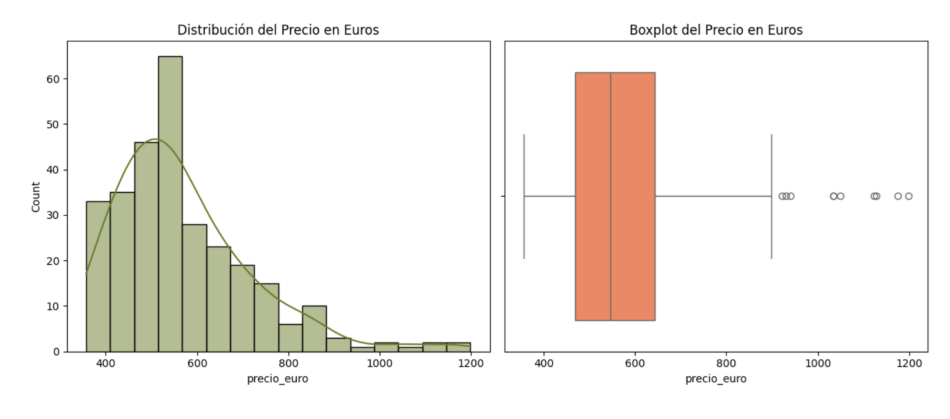

In [ ]:
img = mpimg.imread('Distprecionunoa.png')

plt.figure(figsize=(12, 10)) 
plt.imshow(img)
plt.axis('off')
plt.show()

La mediana del precio está ubicada aproximadamente en los 580 euros y existen aún ciertos outliers, como precios de valor 1200 euros. A este valor se debe incrementar un 20% aproximado por gastos de comunidad (piscina, recogida de basura, espacios comunes) que se paga en todos los edifcios en SCL.  

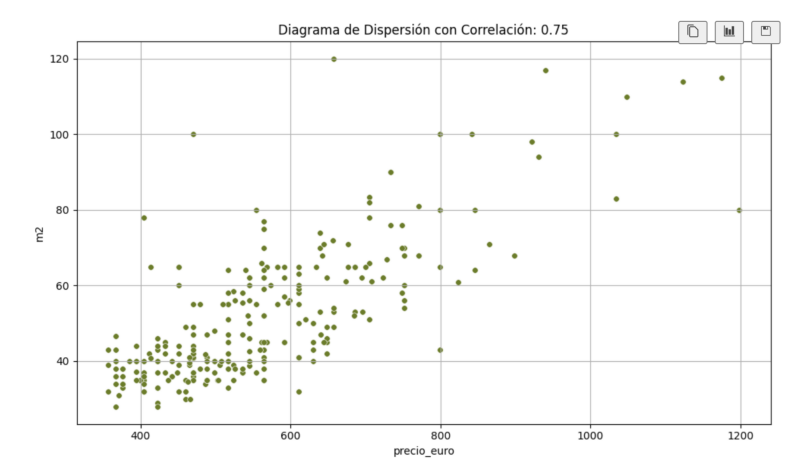

In [13]:
img = mpimg.imread('preciom2.png')

plt.figure(figsize=(10, 8))  
plt.imshow(img)
plt.axis('off')
plt.show()

Como es de esperarse existe una correlación positiva entre el precio y los m2 del piso.

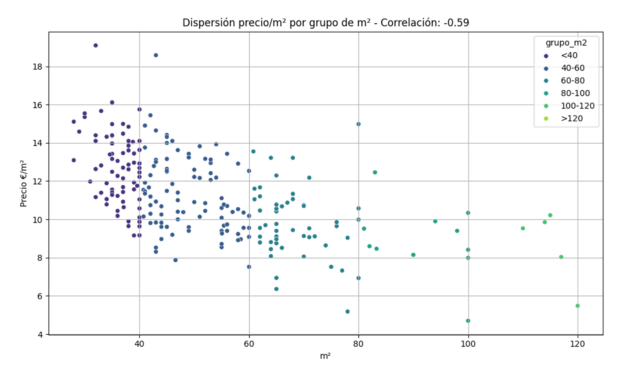

In [16]:
img = mpimg.imread('preciom2m2grupos.png')

plt.figure(figsize=(8, 6))  
plt.imshow(img)
plt.axis('off')
plt.show()

La tendencia general a más m² - menor precio/m², una correlación levemente negariva, lo cuál es normal en el mercado inmobiliario.


Tabla estadística descriptiva del precio en euro/m2 para los distintos grupos por m2 del piso:

| grupo_m2 | count | mean      | std       | min      | 25%      | 50%      | 75%      | max       |
|----------|-------|-----------|-----------|----------|----------|----------|----------|-----------|
| <40      | 103.0 | 24.063103 | 35.741401 | 9.158974 | 11.494410| 12.925000| 14.481081| 169.200000|
| 40-60    | 110.0 | 11.373879 | 1.970691  | 7.520000 | 9.813309 | 11.149784| 12.752336| 18.581395 |
| 60-80    | 61.0  | 9.757163  | 1.808264  | 5.182051 | 8.793548 | 9.551613 | 10.742857| 14.980486 |
| 80-100   | 12.0  | 8.839348  | 1.820056  | 4.700000 | 8.146667 | 8.530981 | 9.612037 | 12.457831 |
| 100-120  | 5.0   | 8.624707  | 1.942531  | 5.483333 | 8.034188 | 9.533036 | 9.855587 | 10.217391 |

La tabla apunta a una disminución del valor medio conforme aumenta grupo_m2, pero con una advertencia importante: el primer grupo tiene mucha variabilidad y posibles outliers, y los grupos más altos tienen muy pocas observaciones. Por tanto, la tendencia parece clara.

##### 5.2 Análisis comparativo entre comunas

El notebook Inmobiliario_gráficos_Todascomunas.ipynb combina los tres DataFrames y realiza análisis comparativos. 

**5.2.1  Test ANOVA — Precio por m² entre comunas**

Se aplicó un ANOVA de una vía para determinar si existen diferencias estadísticamente significativas en el precio por m² entre las tres comunas:  

Estadístico F:	62.2101  
P-valor: 	4.00e-25  
 
Interpretación: con F = 62.21 (muy alto, >10) y p-valor ≈ 0, se rechaza la hipótesis nula. Las diferencias en precio/m² entre comunas no son casualidad, y las diferencias son significativas entre ellas, 62 veces mayores dentro de los grupos que entre ellos.


**5.2.2  Comparación de precios según grupos por m2**

| Tamaño m²   | Precio €/m² Ñuñoa | Precio €/m² Las Condes | Precio €/m² Lo Barnechea |
|------------|------------------|------------------------|---------------------------|
| < 40 m²    | 12,925           | 32,81                  | 24,10                     |
| 40 - 60 m² | 11,14            | 17,55                  | 11,96                     |
| 60 - 80 m² | 9,55             | 19,33                  | 12,09                     |
| 80 - 100 m²| 8,53             | 14,93                  | 9,73                      |
| 100 - 120 m²| 9,53            | 13,22                  | 13,07                     |
| > 120 m²   | -                | 11,75                  | 10,78                     |

Conclusiones importantes:
  
.   Ñuñoa es el distrito más económico en propiedades medianas y grandes.  
.   Tendencia general a más m² - menor precio/m² (normal en el mercado inmobiliario).   
.   Las Condes es el distrito más cara en casi todos los segmentos.  
.   Propiedades pequeñas de alto precio (<40m²).  
.   A partir de 60m² Ñuñoa tiene consistentemente los precios por m² más bajos de las tres comunas, opción más accesible para familias que buscan espacios amplios.  


##### 6. Análisis comparativo alquiler entre Madrid y SCL

 El dataset de Madrid contiene 695 propiedades en alquiler en la zona norte cercana a Tetuán, obtenidas de idealista.com.

Se realizó un filtro en los pisos entre 60 – 80 m2 con 2 habitaciones para ambos dataset y estos fueron los resultados obtenidos:

| Zona | Precio mínimo € | Precio máximo € | Mediana precio € | Mediana precio/m2 |
|---|---:|---:|---:|---:|
| Tetuán - Madrid | 1060€ | 3300€ | 1600 € | 22.8€/m2 |
| Ñuñoa - SCL | 485€ | 1974€ | 767 € ↓48% | 9.6€/m2 |

Comparando la mediana de precios, el alquiler en el ayuntamiento de Ñuñoa es efectivamente un 48% menor que el de la zona de Tetuán en Madrid.

Nota: Se ha aumentado el precio del alquiler en Chile un 20% porque allá se pagan gastos de comunidad muy altos por recogida de basuras, piscina, mantención de espacios comunes y otros.

##### 7. Análisis comparativo alquiler entre Madrid y SCL con otros indicadores

El precio del alquiler está estimado para el criterio de búsqueda de una familia de 3, para un piso de 70m2 con dos baños. 

| Concepto | Ñuñoa - SCL | Tetuán - Madrid | Comparación |
|---|---:|---:|---:|
| Alquiler (60-80m2) | 950 € | 1600 € | ↑ 68% |
| Canasta básica (2026) | 67 € | 149 € | ↑ 120% |
| Costo abono de transporte | 45 € | 33 € | ↓ 27% |
| Costo seguro de salud | 230 – 305 € | 150 – 200 € | ↓ 35% |
| Costo colegios | 500 € | 520 € | ↑ 5% |
| Costo utilites (electricidad – fibra – agua - gas) | 78 € | 115 € | ↑ 47% |

Como el foco está en vivienda y coste de vida básico, Madrid resulta más caro en esta comparación, es el factor que más empuja el coste total hacia arriba en Madrid. 

Sin embargo, el gasto en transporte favorece a Madrid, y el seguro de salud parece penalizar más a Ñuñoa, esto ocurre también porque la calidad de la salud pública en Chile no es muy buena y obliga a las personas a contratar un seguro privado elevando los precios.  

##### 7.Otros indicadores interesantes

**ASEQUIBILIDAD : ALQUILER / SALARIO**  
	
**CAPACIDAD DE AHORRO: SALARIO – GASTOS**


Con un perfil de ingeniero con 15 años de experiencia, el salario estimado en España sería de unos 3.000 € al mes, equivalente a unos 40.000 € brutos anuales (para un extranjero). En Chile, el salario estimado subiría a unos 3.500 € mensuales.

Más allá del salario nominal, la diferencia importante aparece al analizar la asequibilidad. Si se compara el coste del alquiler respecto al salario, España presenta una mayor presión sobre el ingreso disponible. Esto se refleja también en la capacidad de ahorro mensual: en España, con ingresos de 3.000 € y gastos estimados de 3.074 €, el balance sería negativo, de -74 €. En cambio, en Chile, con un salario de 3.500 € y gastos de 2.291 €, el ahorro potencial sería de 1.209 € al mes.

En términos prácticos, esto sugiere que, aunque el salario en ambos países puede parecer similar, la capacidad real de ahorro sería claramente más favorable en Chile. La combinación de un salario algo más alto y unos gastos menores hace que la diferencia en calidad financiera mensual sea significativa.

#### 8. Conclusiones y Hallazgos Principales  
##### 8.1 Santiago de Chile  
•	El precio por m² varía significativamente entre comunas (F=62.21, p<0.001)  
•	Las Condes y Lo Barnechea tienen mayor precio por m² que Ñuñoa en mediana  
•	El precio total en euros NO difiere significativamente entre comunas (p=0.33)  
•	Existe correlación positiva entre precio total y m²: propiedades más grandes cuestan más en total  
•	Existe correlación negativa entre precio/m² y m²: propiedades más grandes tienen menor precio unitario  
•	Los outliers son frecuentes (Las Condes y Ñuñoa muestran máximos extremos: 1745 y 3300 €/m²)  


##### 8.2 Madrid  
•	Zona analizada: norte de Madrid (Bellas Vistas, Berruguete, Ventilla-Almenara, Cuzco-Castillejos)  
•	Rango de precios típico: 800€ - 2.000€/mes para la zona analizada. Los precios demuestran la hipótesis inicial que el costo de vida en Madrid es un 50% mayor que es Santiago de Chile.  
 


8.3 Notas técnicas  

•	**En el archivo utils se han hecho funciones para editar leer y editar los archivos csv, y dejarlos en el formato requerido para el estudio, para hacer el estudio escalable a otros ayuntamentos.**  
•	El tipo de cambio CLP→EUR utilizado es fijo: 1 CLP = 0.00094 EUR (abril 2026)  
•	Los scripts de scraping son reutilizables: cambiar URL y número de páginas para nuevos distritos  
•	Se usa undetected-chromedriver versión compatible con Chrome 146  


#### 9. Referencias
Canasta básica alimentos 2026:  
-- Chile: Ministerio de Desarrollo social y familia  
-- España: www.mercasa.es  
Salario ingeniero:  
-- Chile: Estudio de Sueldos Conexión Ingenieros 2018  
-- Chrome- extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.ingenieros.cl/wp-content/uploads/2019/05/Estudio-de-Sueldos-Conexio%CC%81n-Ingenieros-2018.pdf  
